# Phase 2 — Exploratory Data Analysis

**Goal:** Understand distributions, trends, and relationships in the master dataset before modeling.

Key outputs:
- Correlation matrix (staffing vs outcomes)
- Time series per country
- Regional comparison (North / South / East / West Europe)
- Pre vs post COVID comparison
- Missing data heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED = '../data/processed/'
FIGURES = '../figures/'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv(PROCESSED + 'master_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (864, 14)


,iso3,year,country,region,covid_period,nurses_per_10k,mortality_ami_30d,mortality_stroke_30d,avg_length_of_stay,beds_per_1000,health_exp_pct_gdp,gdp_per_capita,nurses_eurostat_per_100k,nurse_change_rate
0,ALB,2000,Albania,Eastern,pre,NaN,NaN,NaN,NaN,3.21,5.874297,1160.420471,NaN,NaN
1,ALB,2001,Albania,Eastern,pre,NaN,NaN,NaN,NaN,3.17,5.856157,1326.416524,NaN,NaN
2,ALB,2002,Albania,Eastern,pre,NaN,NaN,NaN,NaN,3.09,5.598027,1479.838846,NaN,NaN
3,ALB,2003,Albania,Eastern,pre,NaN,NaN,NaN,NaN,3.05,5.841890,1908.699007,NaN,NaN
4,ALB,2004,Albania,Eastern,pre,NaN,NaN,NaN,NaN,3.04,5.824339,2446.909499,NaN,NaN


## 1. Missing Data Overview

In [2]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(1).to_string())

mortality_stroke_30d        48.1
mortality_ami_30d           45.3
nurse_change_rate           39.2
nurses_eurostat_per_100k    36.5
nurses_per_10k              35.2
avg_length_of_stay          23.5
beds_per_1000                6.6
health_exp_pct_gdp           1.3


## 2. Descriptive Statistics by Region

In [3]:
df.groupby('region')[['nurses_per_10k','mortality_ami_30d','mortality_stroke_30d','avg_length_of_stay']].mean().round(2)

,nurses_per_10k,mortality_ami_30d,mortality_stroke_30d,avg_length_of_stay
region,,,,
Eastern,60.29,7.33,15.19,8.24
Northern,100.55,7.56,9.37,7.67
Southern,46.99,8.36,10.55,8.05
Western,99.92,7.92,9.08,8.75


## 3. Correlation Matrix

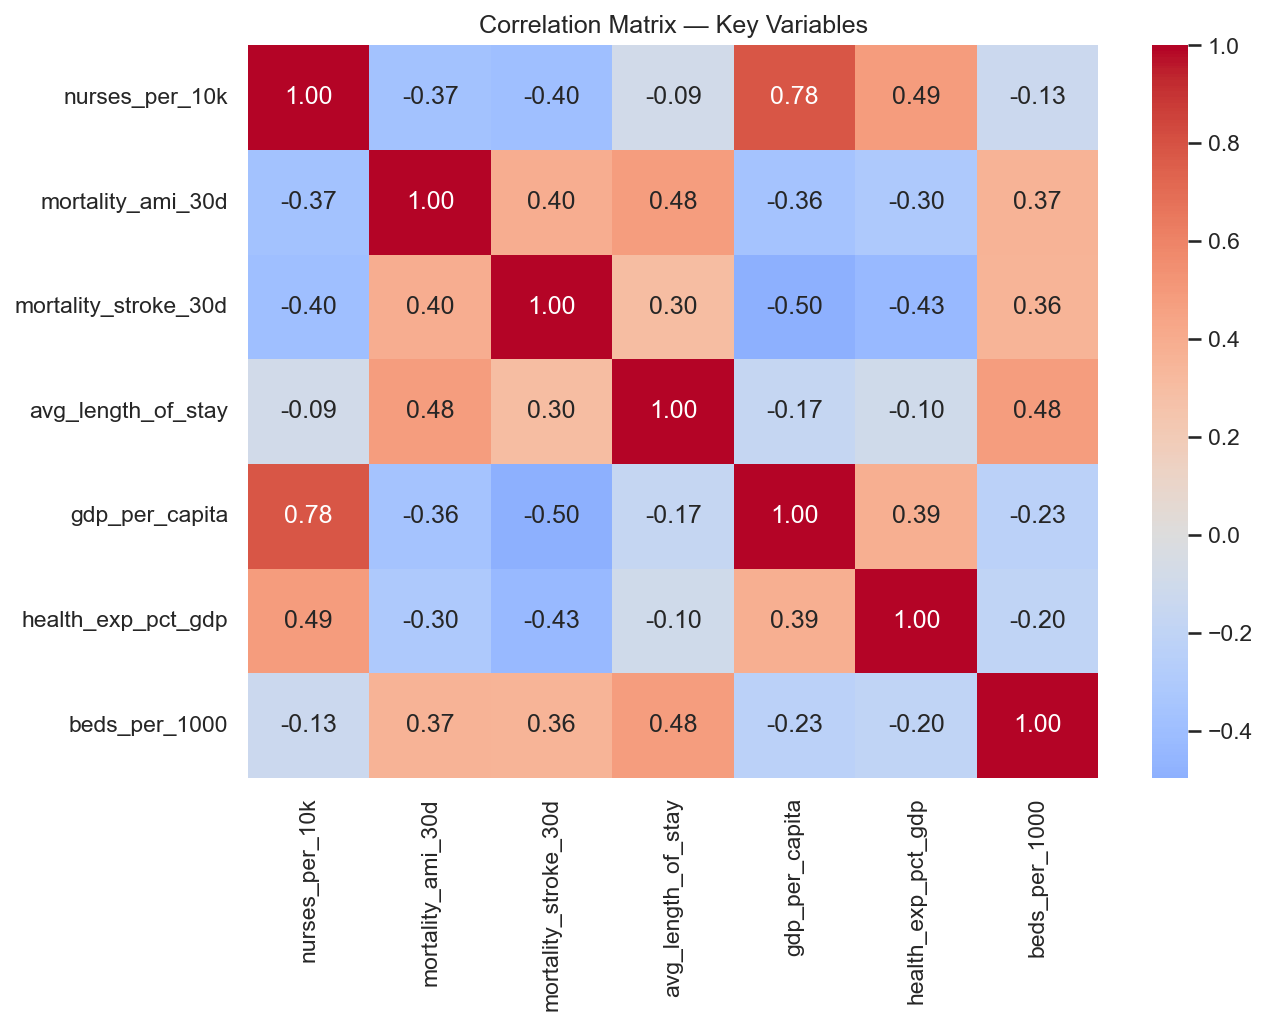

In [4]:
cols = ['nurses_per_10k','mortality_ami_30d','mortality_stroke_30d','avg_length_of_stay','gdp_per_capita','health_exp_pct_gdp','beds_per_1000']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Variables')
plt.tight_layout()
plt.savefig(FIGURES + 'correlation_matrix.png')
plt.show()

## 4. Nurse Staffing Over Time by Region

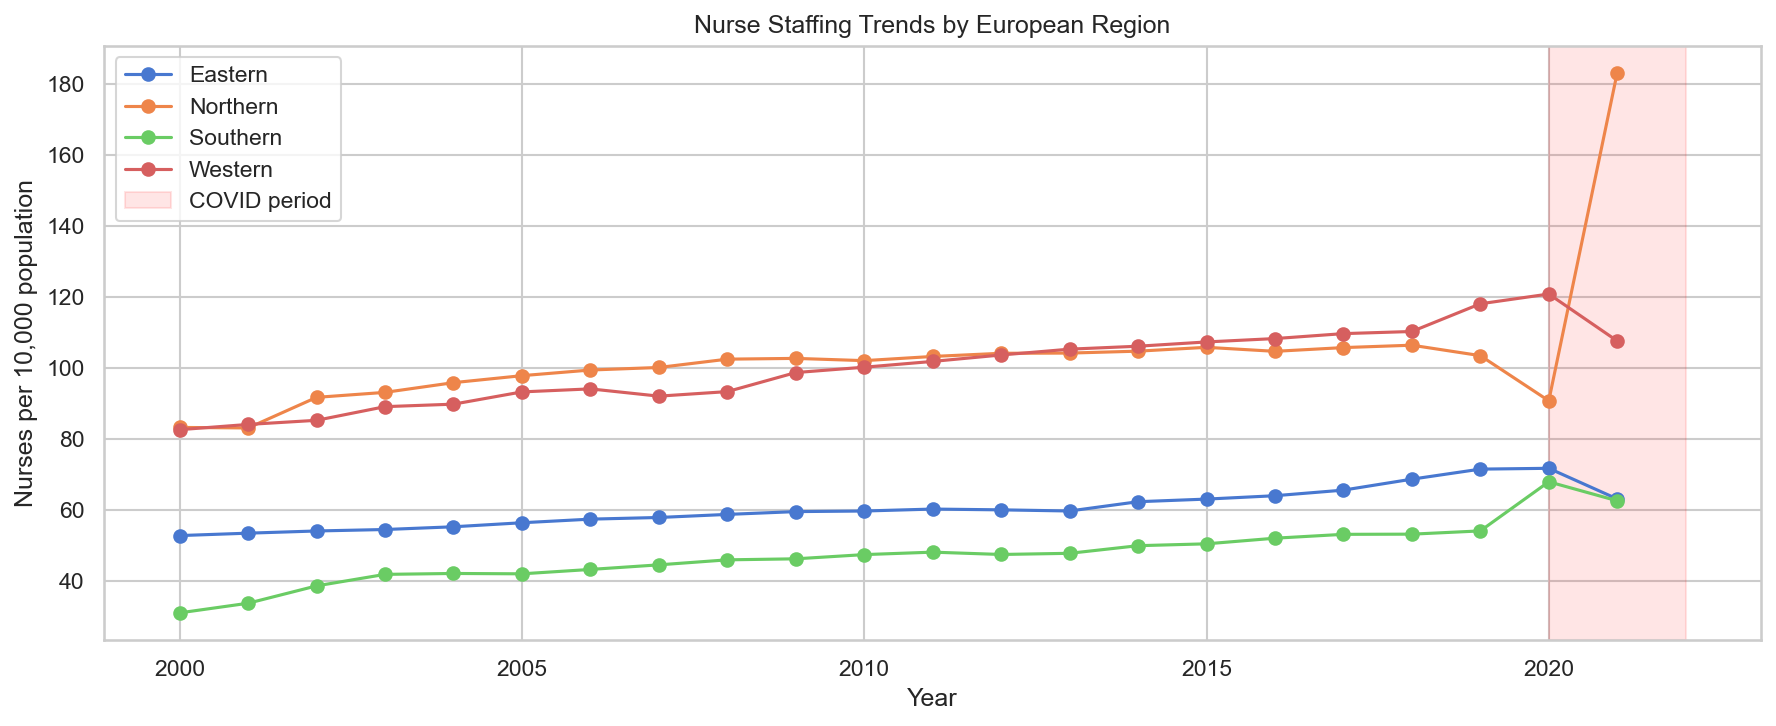

In [5]:
region_year = df.groupby(['year','region'])['nurses_per_10k'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for region, grp in region_year.groupby('region'):
    ax.plot(grp['year'], grp['nurses_per_10k'], marker='o', label=region)
ax.axvspan(2020, 2022, alpha=0.1, color='red', label='COVID period')
ax.set_xlabel('Year')
ax.set_ylabel('Nurses per 10,000 population')
ax.set_title('Nurse Staffing Trends by European Region')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES + 'staffing_trends_by_region.png')
plt.show()

## 5. Nurse Staffing vs AMI Mortality (Scatter)

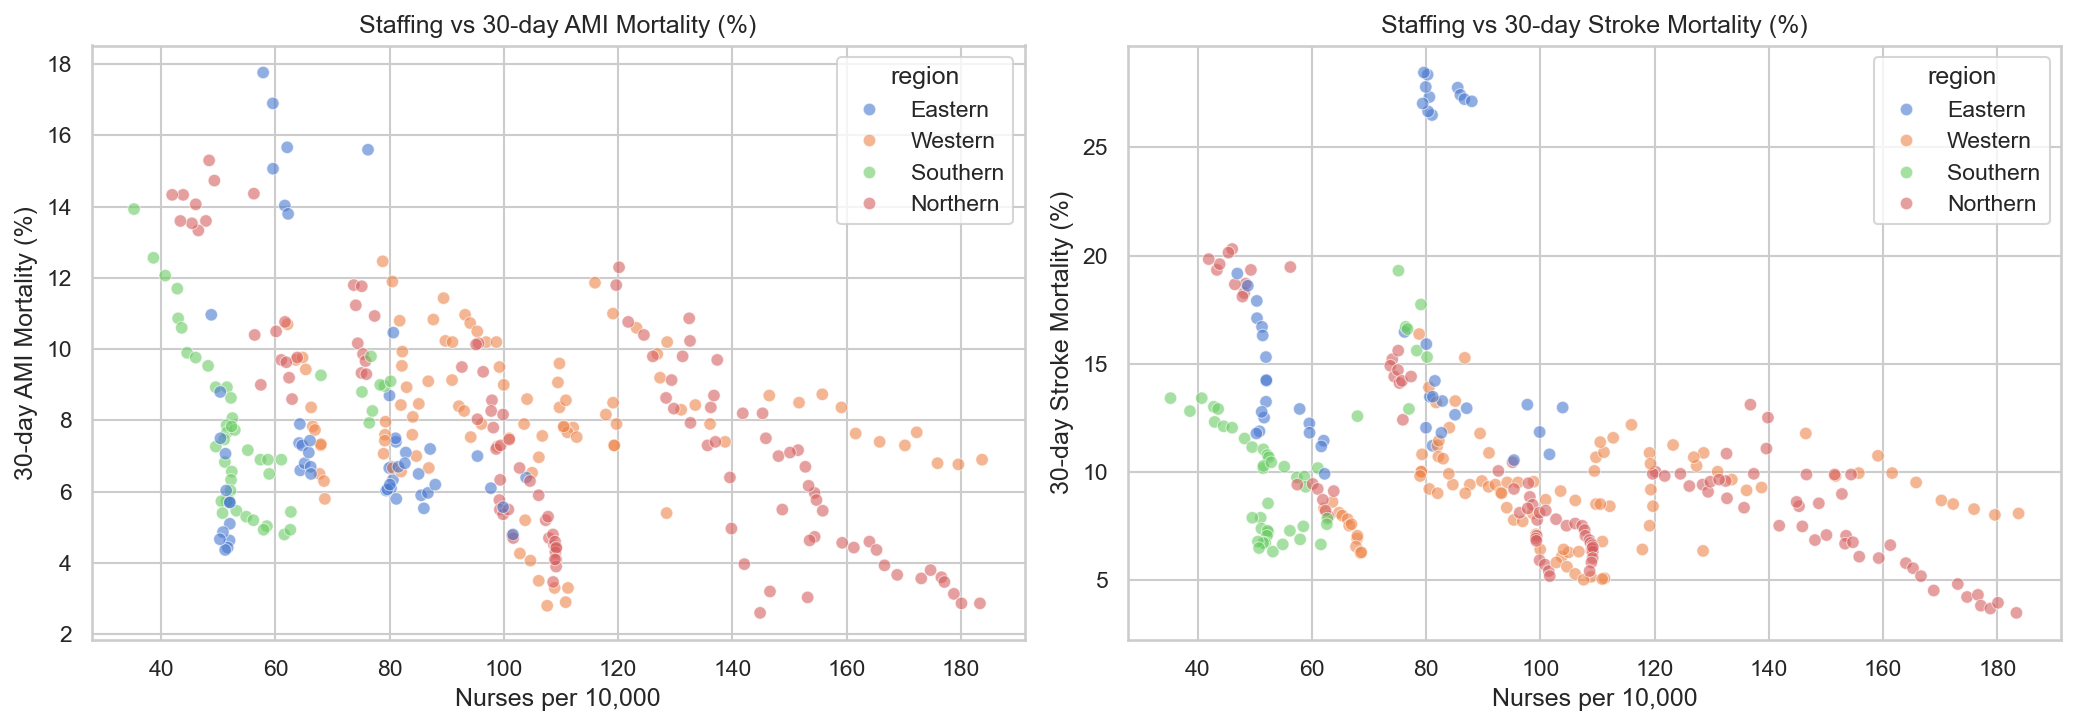

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome, label in zip(axes, ['mortality_ami_30d','mortality_stroke_30d'], ['30-day AMI Mortality (%)','30-day Stroke Mortality (%)']):
    sns.scatterplot(data=df, x='nurses_per_10k', y=outcome, hue='region', ax=ax, alpha=0.6)
    ax.set_xlabel('Nurses per 10,000')
    ax.set_ylabel(label)
    ax.set_title(f'Staffing vs {label}')

plt.tight_layout()
plt.savefig(FIGURES + 'staffing_vs_outcomes_scatter.png')
plt.show()

## 6. Pre vs Post COVID Comparison

In [7]:
covid_compare = df.groupby('covid_period')[['nurses_per_10k','mortality_ami_30d','mortality_stroke_30d','avg_length_of_stay']].mean().round(2)
print(covid_compare)

              nurses_per_10k  mortality_ami_30d  mortality_stroke_30d  \
covid_period                                                            
during                 90.46               7.01                 10.01   
post                     NaN               6.54                  9.67   
pre                    77.99               8.03                 10.60   

              avg_length_of_stay  
covid_period                      
during                      7.70  
post                        7.54  
pre                         8.31  
